# CTM synthetic tracking — analysis notebook

Point `CKPT_DIR` at a training log directory. The notebook loads the latest
checkpoint, runs one sequence through the model with `track=True`, and
produces the following plots:

1. **Sequence preview** — frame strip with GT object positions overlaid.
2. **Certainty over ticks** — shaded by whether MAE is below one bin.
3. **Predicted trajectories at most-certain tick** — predicted vs GT paths on a 2-D map.
4. **Trajectory evolution over ticks** — multi-panel showing how predictions converge.
5. **Per-tick position MAE** — convergence curve for each object.
6. **Position probability heatmaps** — 2-D marginal over (x-bin, y-bin) at the MC tick.
7. **Attention over frames** — which frame tokens the CTM attends to at each tick.
8. **Neuron raster** — post-activations sorted by dominant FFT frequency.
9. **Output-sync trajectory** — PCA/UMAP of the sync vector across ticks.
10. **Synchronisation magnitude** — RMS of action and output sync accumulators.

In [1]:
%load_ext autoreload
%autoreload 2
import os, sys

#REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
REPO_ROOT = "/users/ghermi/code/continuous-thought-machines"
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)
print('repo root:', os.getcwd())

repo root: /home/ghermi/code/continuous-thought-machines


In [2]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

from models.utils import get_latest_checkpoint
from tasks.tracking.dataset import SyntheticTrackingDataset
from tasks.tracking.utils import prepare_model

CKPT_DIR    = 'logs/tracking'   # <- edit me
SAMPLE_INDEX = 0                # which test sample to visualise
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

device: cuda


In [3]:
ckpt_path = get_latest_checkpoint(CKPT_DIR)
print('loading:', ckpt_path)
ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
args = ckpt['args']

test_data = SyntheticTrackingDataset(
    n_samples=args.n_test,
    n_objects=args.n_objects,
    n_frames=args.n_frames,
    img_size=args.img_size,
    n_bins=args.n_bins,
    blob_sigma_px=args.blob_sigma_px,
    velocity_scale=args.velocity_scale,
    seed=args.seed + 1,
)

model = prepare_model(args, DEVICE)

# Initialise lazy modules, then load weights.
dummy_frames, _ = test_data[0]
with torch.no_grad():
    model(dummy_frames.unsqueeze(0).to(DEVICE))
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

N   = args.n_objects
T   = args.n_frames
K   = args.n_bins
ITERS = args.iterations
print(f'Loaded iter {ckpt["iteration"]} | N={N} objects, T={T} frames, K={K} bins, {ITERS} ticks')

loading: logs/tracking/checkpoint_0030000.pt
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
Loaded iter 30000 | N=2 objects, T=8 frames, K=16 bins, 20 ticks


In [4]:

# ── Run a single sample with tracking ─────────────────────────────────────
frames, targets = test_data[SAMPLE_INDEX]
frames_t = frames.unsqueeze(0).to(DEVICE)          # (1, T, 1, H, W)

with torch.inference_mode():
    predictions, certainties, synch_tracks, pre_acts, post_acts, attention = \
        model(frames_t, track=True)

# Strip the batch dimension (B=1) and move everything to numpy.
predictions = predictions.cpu().numpy()[0]           # (N*T*2*K, iters)
certainties = certainties.cpu().numpy()[0]           # (2, iters)
synch_out_track    = synch_tracks[0][:, 0]           # (iters, S_out)
synch_action_track = synch_tracks[1][:, 0]           # (iters, S_action)
post_acts = post_acts[:, 0]                          # (iters, D)
# attention: (iters, heads, 1, T) — one query per tick over T frame tokens
attention = attention[:, 0]                          # (iters, heads, 1, T)

# Reshape predictions → (N, T, 2, K, iters)
# Axis meaning: [object, frame, coord(x=0/y=1), bin, tick]
preds_5d = predictions.reshape(N, T, 2, K, ITERS)

# Decode GT: (T, N, 2) bin indices → normalised coordinates
gt_bins  = targets.numpy()                           # (T, N, 2)
gt_coord = (gt_bins + 0.5) / K                      # (T, N, 2)  in [0,1]

# Most-certain tick
mc_tick  = int(certainties[1].argmax())

# Per-tick MAE  (normalised coords)
def tick_mae(tick):
    # preds_5d[..., tick]: (N, T, 2, K) — argmax over K bins (axis=3)
    pred_bins  = preds_5d[..., tick].argmax(axis=3)  # (N, T, 2)
    pred_coord = (pred_bins + 0.5) / K
    # gt_coord is (T, N, 2); transpose to (N, T, 2) for broadcasting
    return np.abs(pred_coord - gt_coord.transpose(1, 0, 2)).mean()

all_maes = np.array([tick_mae(ti) for ti in range(ITERS)])
mc_mae   = all_maes[mc_tick]

print(f'MC tick: {mc_tick}  |  MAE at MC tick: {mc_mae:.4f}  |  min MAE: {all_maes.min():.4f}')

# Check if this sample contains a crossing (x-ordering flips between t=0 and t=T-1)
init_x  = gt_coord[0, :, 0]     # x-positions at t=0
final_x = gt_coord[-1, :, 0]    # x-positions at t=T-1
is_crossing = not np.array_equal(np.argsort(init_x), np.argsort(final_x))
print(f'Crossing sample: {is_crossing}')


MC tick: 19  |  MAE at MC tick: 0.0332  |  min MAE: 0.0332
Crossing sample: False


## 1. Sequence preview

Frame strip with ground-truth object positions overlaid as coloured markers.
Object identity is preserved across frames — the colours are consistent.

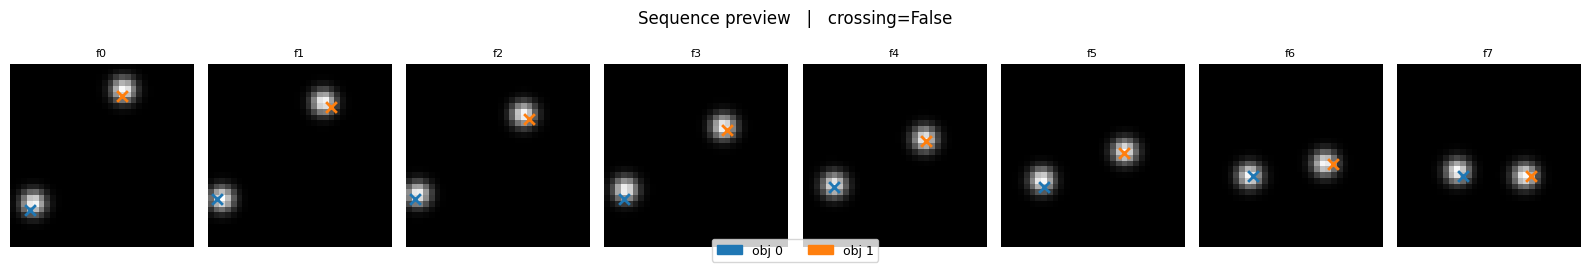

In [5]:
OBJ_COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color'][:N]
H = W = args.img_size

cols = T; rows = 1
fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2.5))
axes = np.array(axes).ravel()
for t in range(T):
    ax = axes[t]
    ax.imshow(frames[t, 0].numpy(), cmap='gray', vmin=0, vmax=1)
    for n in range(N):
        # gt_coord[t, n] = (x, y) in [0,1]; image axes: x→col, y→row
        cx = gt_coord[t, n, 0] * W
        cy = gt_coord[t, n, 1] * H
        ax.scatter(cx, cy, c=OBJ_COLORS[n], s=60, marker='x', linewidths=2)
    ax.set_title(f'f{t}', fontsize=8)
    ax.axis('off')

patches = [mpatches.Patch(color=OBJ_COLORS[n], label=f'obj {n}') for n in range(N)]
fig.legend(handles=patches, loc='lower center', ncol=N, fontsize=9)
fig.suptitle(f'Sequence preview   |   crossing={is_crossing}', fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

## 2. Certainty over ticks

`certainties[1] = 1 − normalised_entropy`. Green shading = ticks where
per-coordinate MAE is below one bin width (1/K); red = above.

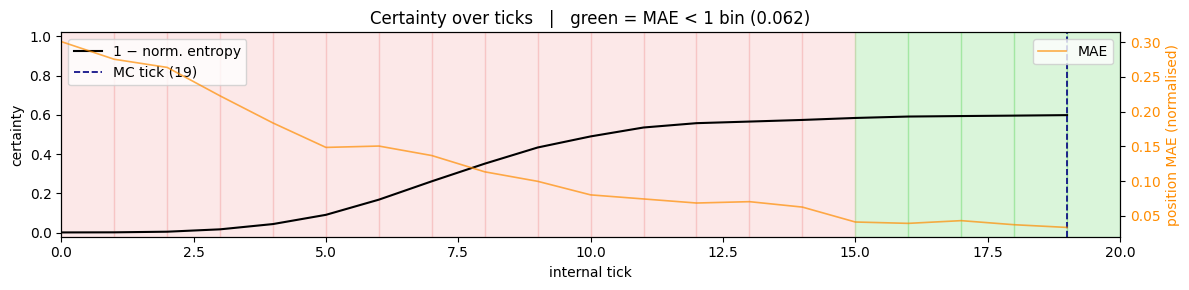

In [6]:
ticks = np.arange(ITERS)
one_bin = 1.0 / K
is_good = all_maes < one_bin

fig, ax = plt.subplots(figsize=(12, 3))
for ti in ticks:
    ax.axvspan(ti, ti + 1, color='limegreen' if is_good[ti] else 'lightcoral', alpha=0.18)
ax.plot(ticks, certainties[1], 'k-', lw=1.5, label='1 − norm. entropy')
ax.axvline(mc_tick, color='navy', lw=1.2, ls='--', label=f'MC tick ({mc_tick})')
ax.set_xlim(0, ITERS)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel('internal tick')
ax.set_ylabel('certainty')
ax.set_title(f'Certainty over ticks   |   green = MAE < 1 bin ({one_bin:.3f})')
ax.legend()

ax2 = ax.twinx()
ax2.plot(ticks, all_maes, color='darkorange', lw=1.2, alpha=0.7, label='MAE')
ax2.set_ylabel('position MAE (normalised)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.legend(loc='upper right')

fig.tight_layout()
plt.show()

## 3. Predicted trajectories at most-certain tick

Ground-truth paths (solid) vs predicted paths (dashed) on a 2-D unit square.
Markers at each frame; colours encode object identity.

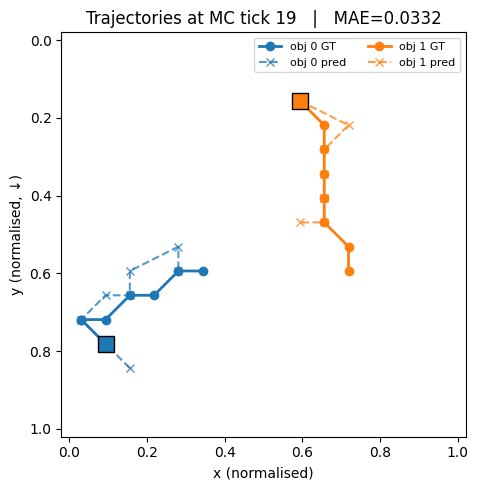

In [7]:

def decode_coords(tick):
    """Return (N, T, 2) predicted normalised coordinates at a given tick."""
    # preds_5d[..., tick] is (N, T, 2, K); argmax over K bins = axis 3
    pred_bins = preds_5d[..., tick].argmax(axis=3)   # (N, T, 2)
    return (pred_bins + 0.5) / K

pred_coord_mc = decode_coords(mc_tick)               # (N, T, 2)  — x, y in [0,1]
# gt_coord: (T, N, 2) → transpose to (N, T, 2)
gt_traj = gt_coord.transpose(1, 0, 2)               # (N, T, 2)

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')
ax.invert_yaxis()  # image convention: y increases downward

for n in range(N):
    c = OBJ_COLORS[n]
    # GT trajectory
    ax.plot(gt_traj[n, :, 0], gt_traj[n, :, 1],
            '-o', color=c, lw=2, ms=6, label=f'obj {n} GT')
    # Predicted trajectory
    ax.plot(pred_coord_mc[n, :, 0], pred_coord_mc[n, :, 1],
            '--x', color=c, lw=1.5, ms=6, alpha=0.75, label=f'obj {n} pred')
    # Start marker
    ax.scatter(gt_traj[n, 0, 0], gt_traj[n, 0, 1],
               c=c, s=120, marker='s', zorder=5, edgecolor='k')

ax.set_xlabel('x (normalised)')
ax.set_ylabel('y (normalised, ↓)')
ax.set_title(f'Trajectories at MC tick {mc_tick}   |   MAE={mc_mae:.4f}')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()


## 4. Trajectory evolution over ticks

Predicted paths at evenly spaced ticks. Early ticks are noisy; the model
should converge to the GT layout as internal recurrence progresses.

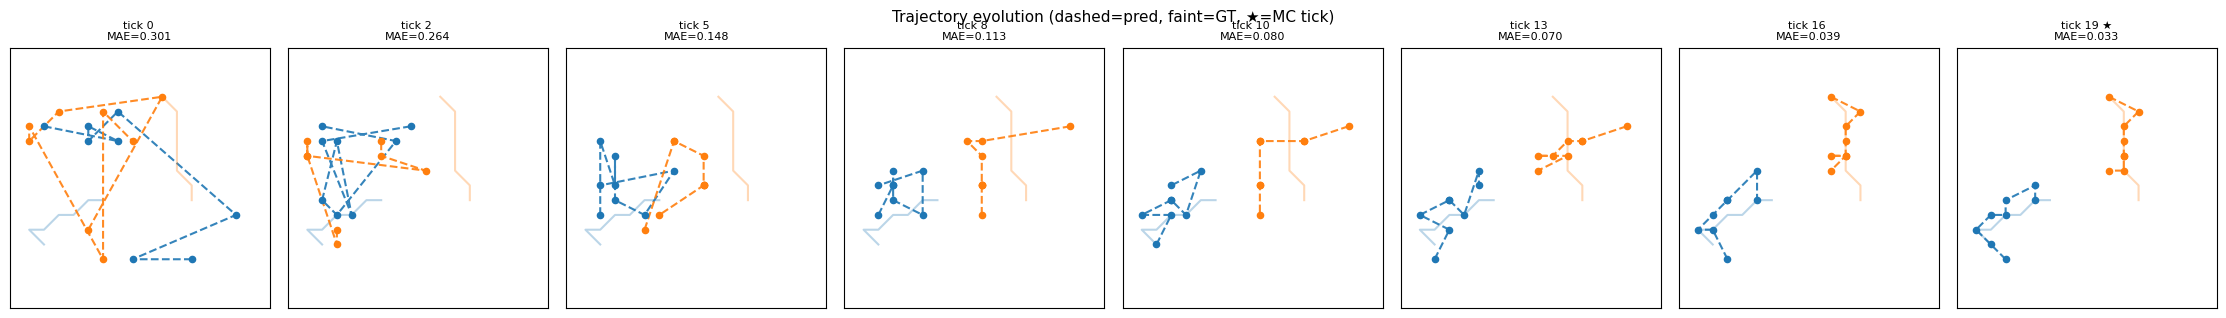

In [8]:
N_PANELS = min(8, ITERS)
snap_ticks = np.linspace(0, ITERS - 1, N_PANELS, dtype=int)

fig, axes = plt.subplots(1, N_PANELS, figsize=(2.8 * N_PANELS, 3.2))
for pi, ti in enumerate(snap_ticks):
    ax = axes[pi]
    pred_c = decode_coords(ti)                       # (N, T, 2)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    for n in range(N):
        c = OBJ_COLORS[n]
        ax.plot(gt_traj[n, :, 0], gt_traj[n, :, 1],
                '-', color=c, lw=1.5, alpha=0.3)
        ax.plot(pred_c[n, :, 0], pred_c[n, :, 1],
                '--', color=c, lw=1.5, alpha=0.9)
        for t in range(T):
            ax.scatter(pred_c[n, t, 0], pred_c[n, t, 1],
                       c=c, s=20, zorder=4)
    star = '★' if ti == mc_tick else ''
    ax.set_title(f'tick {ti} {star}\nMAE={all_maes[ti]:.3f}', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle('Trajectory evolution (dashed=pred, faint=GT, ★=MC tick)', fontsize=11)
fig.tight_layout()
plt.show()

## 5. Per-tick position MAE

Overall MAE plus per-object MAE over internal ticks. The model should drive
error down and reach its minimum near the most-certain tick.

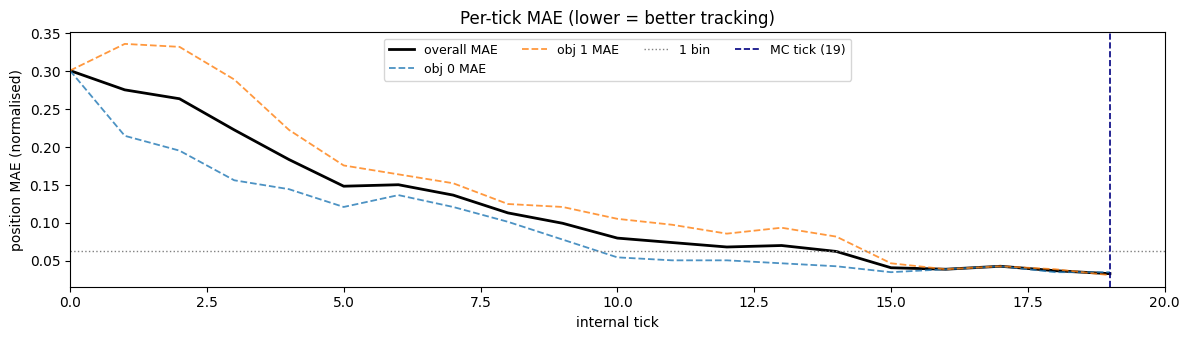

In [9]:

# Per-object MAE at each tick
obj_maes = np.zeros((N, ITERS))
for n in range(N):
    for ti in range(ITERS):
        # preds_5d[n, :, :, :, ti] is (T, 2, K); argmax over K bins = axis 2
        pred_bins  = preds_5d[n, :, :, :, ti].argmax(axis=2)   # (T, 2)
        pred_coord = (pred_bins + 0.5) / K
        obj_maes[n, ti] = np.abs(pred_coord - gt_coord[:, n]).mean()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(ticks, all_maes, 'k-', lw=2, label='overall MAE')
for n in range(N):
    ax.plot(ticks, obj_maes[n], '--', color=OBJ_COLORS[n],
            lw=1.3, alpha=0.8, label=f'obj {n} MAE')
ax.axhline(1.0 / K, color='grey', ls=':', lw=1, label='1 bin')
ax.axvline(mc_tick, color='navy', ls='--', lw=1.2, label=f'MC tick ({mc_tick})')
ax.set_xlabel('internal tick')
ax.set_ylabel('position MAE (normalised)')
ax.set_title('Per-tick MAE (lower = better tracking)')
ax.legend(ncol=N + 2, fontsize=9)
ax.set_xlim(0, ITERS)
fig.tight_layout()
plt.show()


## 6. Position probability heatmaps at MC tick

For each object at each frame, the model predicts independent K-bin distributions
over x and y. Their outer product gives a K×K joint probability map.
GT bin is marked with a cross; the peak of the heatmap should align with it.

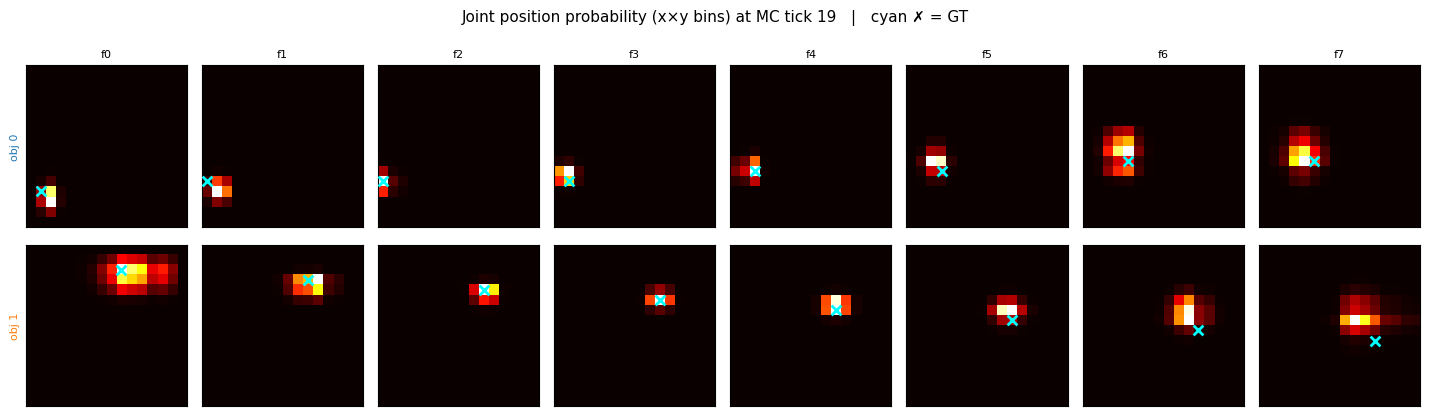

In [10]:
def softmax(z):
    z = z - z.max()
    e = np.exp(z)
    return e / e.sum()

fig, axes = plt.subplots(N, T, figsize=(1.8 * T, 2.2 * N))
if N == 1:
    axes = axes[np.newaxis, :]

for n in range(N):
    for t in range(T):
        ax = axes[n, t]
        x_probs = softmax(preds_5d[n, t, 0, :, mc_tick])   # (K,)  x-axis
        y_probs = softmax(preds_5d[n, t, 1, :, mc_tick])   # (K,)  y-axis
        hmap = np.outer(y_probs, x_probs)                   # (K, K)
        ax.imshow(hmap, origin='upper', cmap='hot',
                  extent=[0, 1, 1, 0], aspect='equal')
        # GT position
        gx = gt_coord[t, n, 0]
        gy = gt_coord[t, n, 1]
        ax.scatter(gx, gy, c='cyan', s=50, marker='x', linewidths=2, zorder=5)
        ax.set_xticks([]); ax.set_yticks([])
        if t == 0:
            ax.set_ylabel(f'obj {n}', fontsize=8, color=OBJ_COLORS[n])
        if n == 0:
            ax.set_title(f'f{t}', fontsize=8)

fig.suptitle(f'Joint position probability (x×y bins) at MC tick {mc_tick}   |   cyan ✗ = GT',
             fontsize=11)
fig.tight_layout()
plt.show()

## 7. Attention over frame tokens

Unlike the video tasks, there is no spatial attention here — the CTM attends
over T frame tokens (one per frame). The heatmap below shows which frames
the model focuses on at each internal tick. The diagonal pattern would mean
the model processes frames in order; a more uniform pattern means it integrates
all temporal context simultaneously.

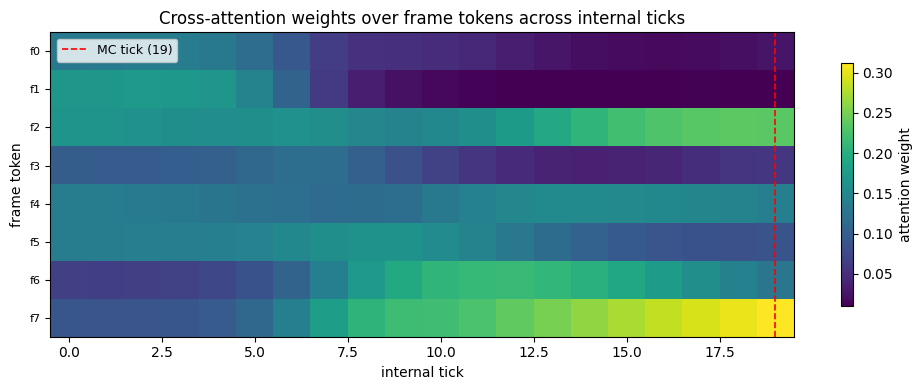

In [11]:
# attention: (iters, heads, 1, T)
# Average over heads, squeeze query dim → (iters, T)
attn_map = attention.mean(axis=1)[:, 0, :]       # (iters, T)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(attn_map.T, aspect='auto', cmap='viridis', origin='upper')
ax.set_xlabel('internal tick')
ax.set_ylabel('frame token')
ax.set_yticks(range(T))
ax.set_yticklabels([f'f{t}' for t in range(T)], fontsize=8)
ax.axvline(mc_tick, color='red', lw=1.2, ls='--', label=f'MC tick ({mc_tick})')
ax.legend(fontsize=9)
ax.set_title('Cross-attention weights over frame tokens across internal ticks')
plt.colorbar(im, ax=ax, shrink=0.8, label='attention weight')
fig.tight_layout()
plt.show()

## 8. Neuron raster

Post-activation of a subset of CTM neurons across internal ticks, sorted by
dominant FFT frequency. The key CTM claim: different neurons develop
different temporal response profiles (oscillators, ramps, bursts).

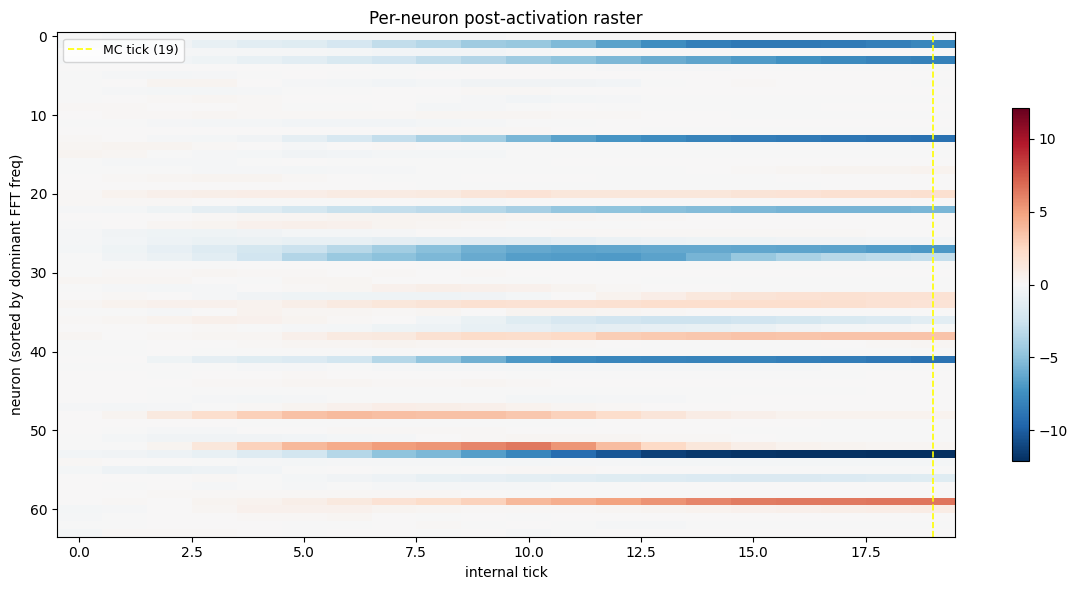

In [12]:
N_NEURONS = min(64, post_acts.shape[1])

fft_mag  = np.abs(np.fft.rfft(post_acts, axis=0))[1:]   # skip DC; (freqs, D)
peak_bin = fft_mag.argmax(axis=0)                        # (D,)
order    = np.argsort(peak_bin)
chosen   = order[np.linspace(0, len(order) - 1, N_NEURONS).astype(int)]
raster   = post_acts[:, chosen].T                        # (N_NEURONS, iters)

fig, ax = plt.subplots(figsize=(12, 6))
lim = max(np.abs(raster).max(), 1e-6)
im  = ax.imshow(raster, aspect='auto', cmap='RdBu_r',
                vmin=-lim, vmax=lim, interpolation='nearest')
ax.axvline(mc_tick, color='yellow', lw=1.2, ls='--', label=f'MC tick ({mc_tick})')
ax.set_xlabel('internal tick')
ax.set_ylabel('neuron (sorted by dominant FFT freq)')
ax.set_title('Per-neuron post-activation raster')
ax.legend(fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.7)
fig.tight_layout()
plt.show()

## 9. Output-sync trajectory (PCA / UMAP)

The output-synchronisation vector is what drives the position predictions.
Its trajectory through a 2-D projection shows how the latent representation
evolves: early ticks explore, later ticks settle.

/users/ghermi/miniconda3/envs/ctm/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


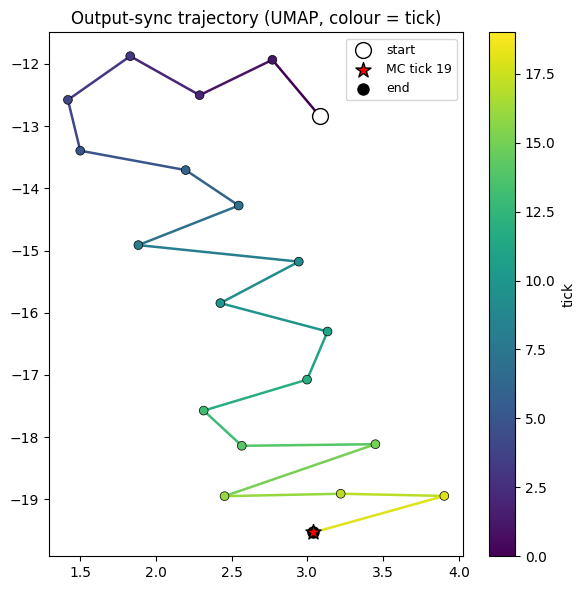

In [13]:
sync = synch_out_track                              # (iters, S_out)

try:
    import umap
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=min(15, max(2, ITERS - 1)),
        min_dist=0.4, metric='cosine', random_state=0,
    )
    emb = reducer.fit_transform(sync)
    method = 'UMAP'
except Exception as e:
    print('UMAP unavailable, falling back to PCA:', e)
    from sklearn.decomposition import PCA
    emb = PCA(n_components=2).fit_transform(sync)
    method = 'PCA'

fig, ax = plt.subplots(figsize=(6, 6))
cmap = plt.cm.viridis
for i in range(len(emb) - 1):
    ax.plot(emb[i:i+2, 0], emb[i:i+2, 1], '-',
            color=cmap(i / max(1, len(emb) - 1)), lw=1.8)
sc = ax.scatter(emb[:, 0], emb[:, 1], c=np.arange(ITERS),
                cmap='viridis', s=40, edgecolor='k', lw=0.5, zorder=3)
ax.scatter(*emb[0],      c='white', edgecolor='black', s=130, zorder=5, label='start')
ax.scatter(*emb[mc_tick], c='red',   edgecolor='black', s=130,
           marker='*', zorder=6, label=f'MC tick {mc_tick}')
ax.scatter(*emb[-1],     c='black', edgecolor='white', s=100, zorder=5, label='end')
plt.colorbar(sc, ax=ax, label='tick')
ax.legend(fontsize=9)
ax.set_title(f'Output-sync trajectory ({method}, colour = tick)')
fig.tight_layout()
plt.show()

## 10. Synchronisation magnitude

RMS of the action-sync and output-sync vectors per tick. The leaky
accumulators build up evidence as more ticks process the same sequence;
the shape reflects the learned time constants.

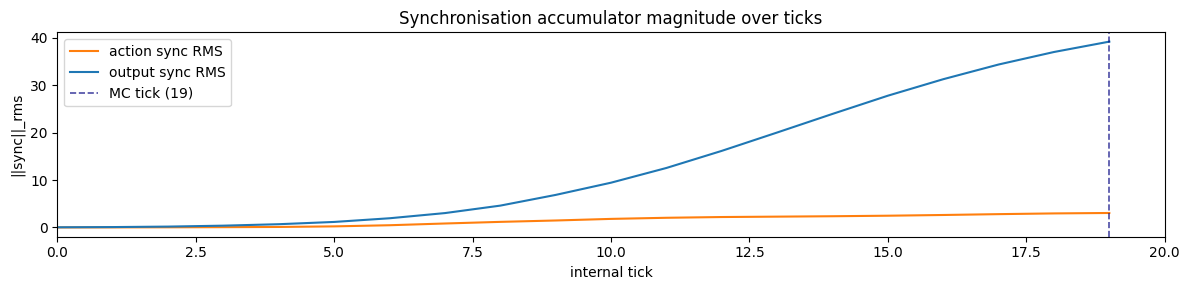

In [14]:
sa = np.sqrt((synch_action_track ** 2).mean(axis=-1))   # (iters,)
so = np.sqrt((synch_out_track    ** 2).mean(axis=-1))   # (iters,)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(ticks, sa, label='action sync RMS', color='tab:orange', lw=1.5)
ax.plot(ticks, so, label='output sync RMS', color='tab:blue',   lw=1.5)
ax.axvline(mc_tick, color='navy', lw=1.2, ls='--', alpha=0.7,
           label=f'MC tick ({mc_tick})')
ax.set_xlabel('internal tick')
ax.set_ylabel('||sync||_rms')
ax.set_title('Synchronisation accumulator magnitude over ticks')
ax.set_xlim(0, ITERS)
ax.legend()
fig.tight_layout()
plt.show()